This is the selfish elite model shown in the mathematical appendix A in Peter Turchin's Historical Dynamics.

Variable Labeling:
- beta1 and beta2: Represents the rate of food to poulation growth for producers and elites
- rho0: Food per producer
- g0: Production drop at population carrying capacity
- delta1: Death rate of producers
- delta2 or the death rate of elites is modelled by c1/(1+c2*S)
- S: The state resources
- gamma: tax rate from elites to state
- c: productivity decline due to state resources effect on carrying capacity
- a: amount of producers elites can extract from
- c1: The maximum extinction rate, which occurs when S = 0
- c2: How fast the extinction rate declines with increasing S
- alpha: proportionality constant relating elite numbers to state expenditures
- h: adjusts effect of fiscal health on productivity


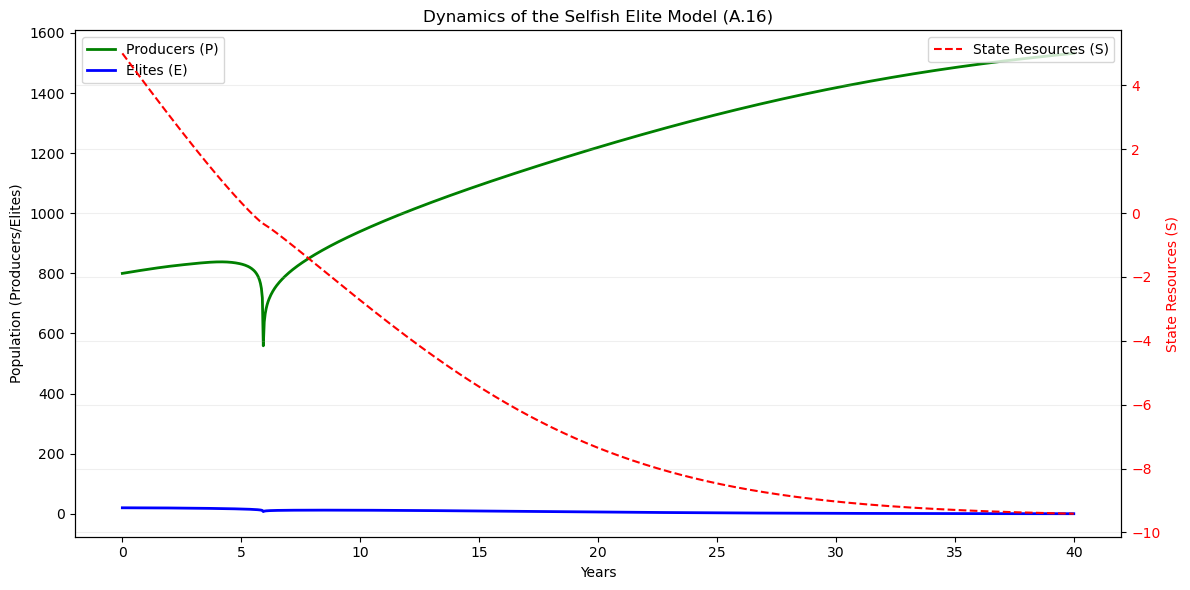

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def selfish_elite_model(t, PES, beta1, rho0, g0, a, delta1, beta2, gamma, alpha, h, c, c1, c2):
    # Unpack variables from PES vector for producers, elites, and state resources
    P, E, S = PES
    g_S = g0 * (h + S) / (h + (1 + c) * S)
    dPdt = (beta1 * rho0 * (1 - g_S * P) * P) / (1 + a * E) - delta1 * P
    dEdt = (beta2 * rho0 * a * E * (1 - g_S * P) * P) / (1 + a * E) - c1/(1+c2*S)* E
    revenue = gamma * max(0, dEdt)
    expenditure = alpha * E
    dSdt = gamma * E - alpha * E
    return [dPdt, dEdt, dSdt]

params = {
    'beta1': 0.2,      # Producer birth coefficient
    'delta1': 0.1,     # Producer death rate
    'beta2': 0.05,     # Elite birth coefficient
    'rho0': 1.0,       # Maximum production rate
    'g0': 0.001,       # Base carrying capacity parameter
    'a': 0.01,         # Elite control parameter
    'gamma': 0.05,     # Tax rate - REDUCED (elites keep most extraction)
    'alpha': 0.1,      # State expenditure per elite - INCREASED (state costs more)
    'h': 1.0,          # Fiscal health parameter
    'c': 2.0,          # Productivity decline factor
    'c1': 0.3,         # Maximum elite death rate (increased competition)
    'c2': 0.05,        # Elite mortality sensitivity to S
}

# Initial Conditions
y0 = [800, 20, 5]

# Define time span and evaluation points
t_span = (0, 40)  # 500 years
t_eval = np.linspace(t_span[0], t_span[1], 1000)

# Unpack params in the correct order for the function
solution = solve_ivp(
    selfish_elite_model, 
    t_span, 
    y0, 
    t_eval=t_eval,
    args=(
        params['beta1'], 
        params['rho0'], 
        params['g0'], 
        params['a'], 
        params['delta1'], 
        params['beta2'], 
        params['gamma'], 
        params['alpha'], 
        params['h'], 
        params['c'],
        params['c1'],
        params['c2'] 
    )
)

# Plotting
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_xlabel('Years')
ax1.set_ylabel('Population (Producers/Elites)', color='black')
ax1.plot(solution.t, solution.y[0], label='Producers (P)', color='green', linewidth=2)
ax1.plot(solution.t, solution.y[1], label='Elites (E)', color='blue', linewidth=2)
ax1.tick_params(axis='y')

ax2 = ax1.twinx()
ax2.set_ylabel('State Resources (S)', color='red')
ax2.plot(solution.t, solution.y[2], label='State Resources (S)', color='red', linestyle='--')
ax2.tick_params(axis='y', labelcolor='red')

plt.title("Dynamics of the Selfish Elite Model (A.16)")
fig.tight_layout()
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid(alpha=0.2)
plt.show()

However, due to how the integrate function works in Scipy, the state resources hitting 0 causes the program to end. This is unsurprising, as this is the point where state collapse occurs. I have tried adding a reset function. However, it becomes clear that this model does not work well for tracking cycles between populations. 

Dynasty collapse at t=4.3 years - P:938, E:23
Dynasty collapse at t=16.9 years - P:1664, E:22
Dynasty collapse at t=25.4 years - P:2060, E:29
Dynasty collapse at t=32.8 years - P:2303, E:32
Dynasty collapse at t=39.7 years - P:2456, E:33
Dynasty collapse at t=46.4 years - P:2500, E:30
Dynasty collapse at t=53.0 years - P:2554, E:32
Dynasty collapse at t=59.5 years - P:2601, E:33
Dynasty collapse at t=66.0 years - P:2563, E:28
Dynasty collapse at t=72.5 years - P:2596, E:32
Dynasty collapse at t=79.0 years - P:2568, E:29
Dynasty collapse at t=85.5 years - P:2592, E:32
Dynasty collapse at t=92.0 years - P:2572, E:29
Dynasty collapse at t=98.5 years - P:2589, E:31


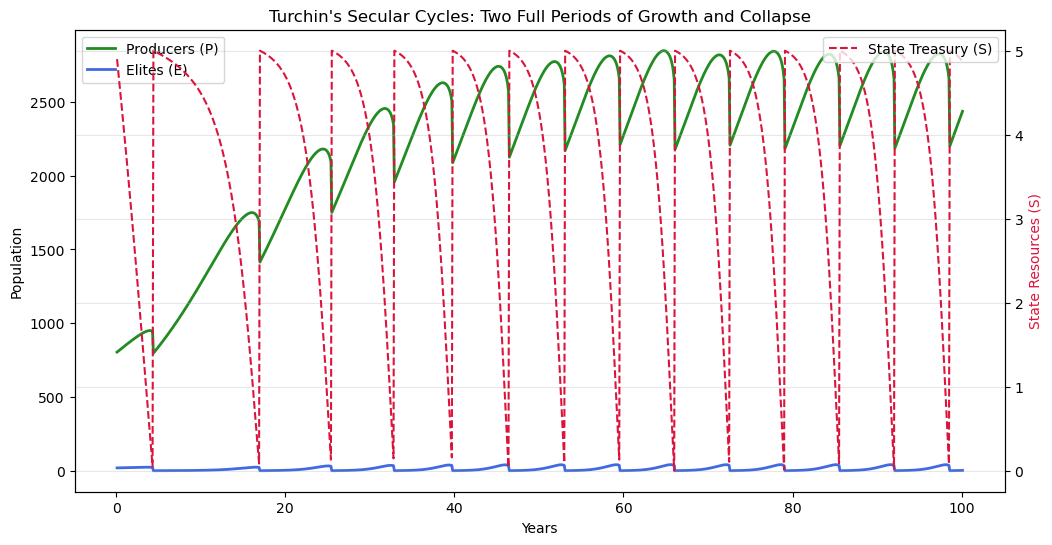

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def simulate_two_cycles(PES, params, total_years, dt):
    # Initial Conditions (A new dynasty starts)
    P, E, S = PES
    
    # Store history for plotting
    history = {'t': [], 'P': [], 'E': [], 'S': []}
    
    # Extract params for readability
    b1, d1 = params['beta1'], params['delta1']
    b2= params['beta2']
    rho0, g0, a = params['rho0'], params['g0'], params['a']
    gamma, alpha, h, c = params['gamma'], params['alpha'], params['h'], params['c']
    c1, c2 = params['c1'], params['c2']

    t = 0
    while t < total_years:
        # 1. State-Dependent Carrying Capacity (g_S)
        # g(S) from equation A.15
        g_S = g0 * h / (h + (1 + c) * S)
        
        # Equation A.16
        dPdt = (b1 * rho0 * (1 - g_S * P) * P) / (1 + a * E) - d1 * P
        
        dEdt = (b2 * rho0 * a * E * (1 - g_S * P) * P) / (1 + a * E) - (c1 * E) / (1 + c2 * S)
        
        dSdt = gamma * E - alpha * E
        
        # Euler integration
        P_new = P + dPdt * dt
        E_new = E + dEdt * dt
        S_new = S + dSdt * dt
        
        P = max(0, P_new)
        E = max(0, E_new)
        S = max(0, S_new)
        
        # Dynasty collapse when S hits zero
        if S_new <= 0 and S <= 0:
            print(f"Dynasty collapse at t={t:.1f} years - P:{P:.0f}, E:{E:.0f}")
            S = 5      # New dynasty gets initial treasury
            P *= 0.85     # Population crisis
            E = 1.0      # New elite takes over
        
        t += dt
        history['t'].append(t)
        history['P'].append(P)
        history['E'].append(E)
        history['S'].append(S)
        
    return history
# Model Parameters
model_params = {
    'beta1': 0.2,      # Producer birth coefficient
    'delta1': 0.1,     # Producer death rate
    'beta2': 0.05,     # Elite birth coefficient
    'rho0': 1.0,       # Maximum production rate
    'g0': 0.001,       # Base carrying capacity parameter
    'a': 0.01,         # Elite control parameter
    'gamma': 0.05,     # Tax rate - REDUCED (elites keep most extraction)
    'alpha': 0.1,      # State expenditure per elite - INCREASED (state costs more)
    'h': 1.0,          # Fiscal health parameter
    'c': 2.0,          # Productivity decline factor
    'c1': 0.3,         # Maximum elite death rate (increased competition)
    'c2': 0.05,        # Elite mortality sensitivity to S
}
PES=[800.0, 20.0, 5.0]  # Initial Conditions: Producers, Elites, State Resources
# Simulate two full cycles
data = simulate_two_cycles(PES, model_params, total_years=100, dt=0.1)

# Plotting
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel('Years')
ax1.set_ylabel('Population')
ax1.plot(data['t'], data['P'], label='Producers (P)', color='forestgreen', linewidth=2)
ax1.plot(data['t'], np.array(data['E']), label='Elites (E)', color='royalblue', linewidth=2)

ax2 = ax1.twinx()
ax2.set_ylabel('State Resources (S)', color='crimson')
ax2.plot(data['t'], data['S'], label='State Treasury (S)', color='crimson', linestyle='--')

plt.title("Turchin's Secular Cycles: Two Full Periods of Growth and Collapse")
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.show()

Simulating Ibn Khaldun models...
Simulating parasitic nomads model...


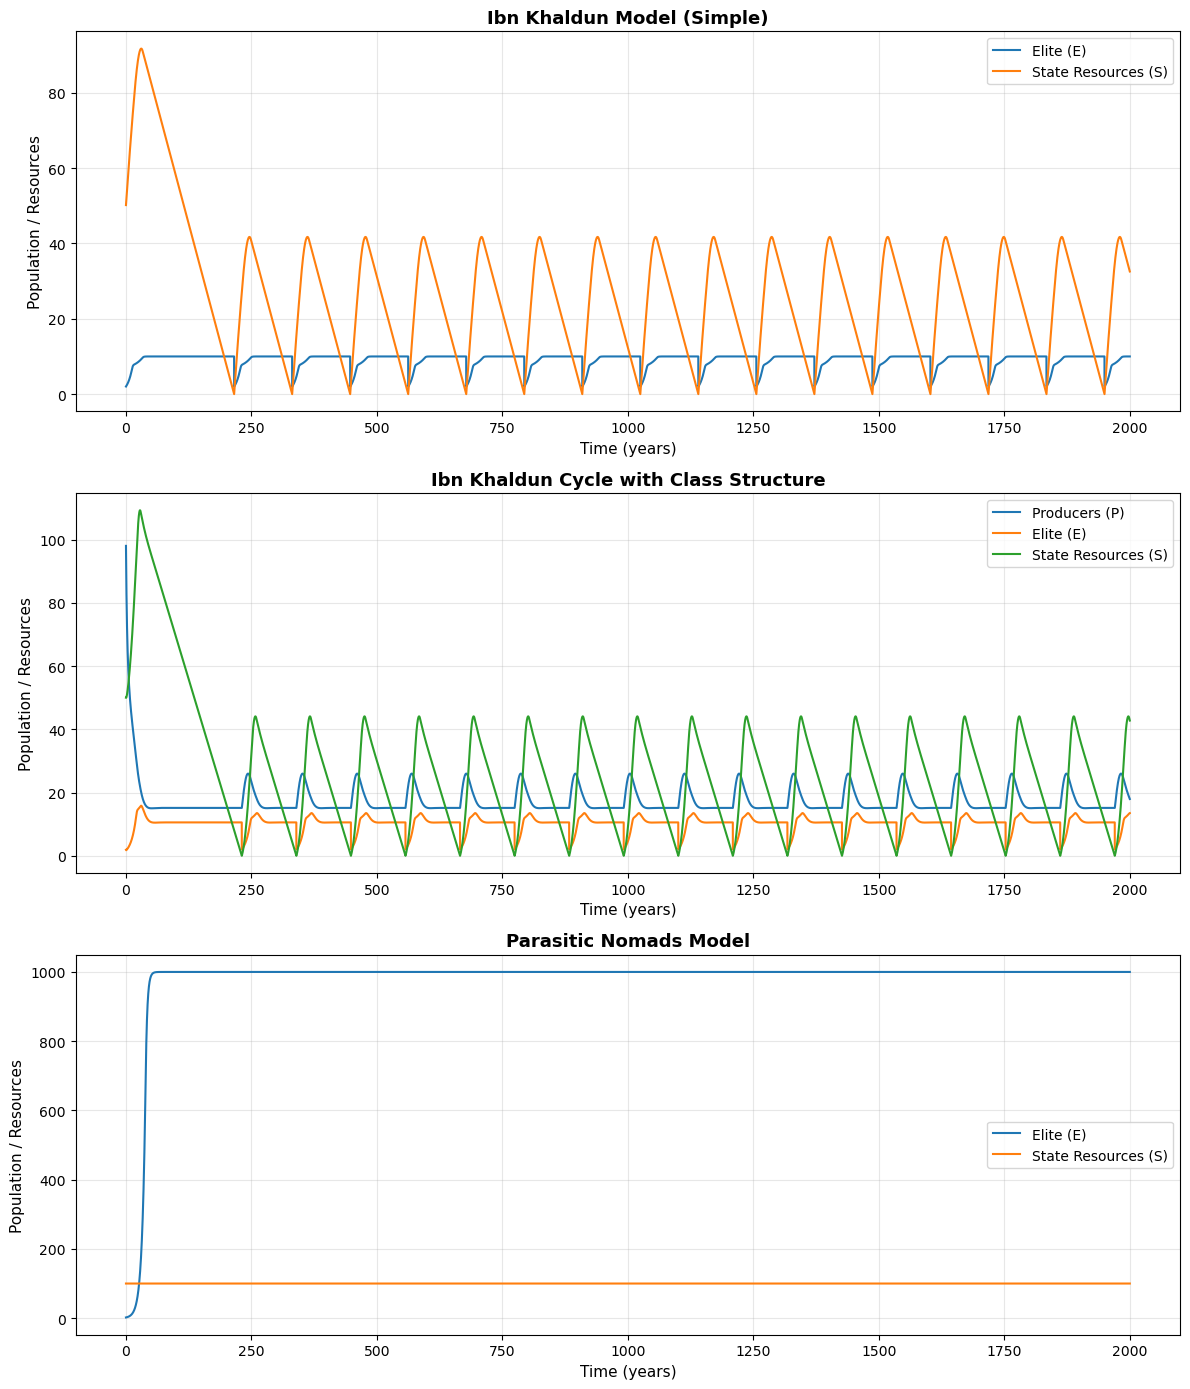

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_ibn_khaldun_models(years=2000, dt=0.1):
    """
    Simulate Ibn Khaldun dynasty models based on Turchin's Mathematical Appendix.
    
    Parameters:
    - years: Total simulation time in years
    - dt: Time step size in years (0.1 = ~1.2 months)
    """
    steps = int(years / dt)
    
    # --- Parameters for Model 1: Ibn Khaldun (Simple) [p.212] ---
    R = 10.0         # Resources extracted (constant)
    gamma = 0.2      # Tax fraction
    chi = 0.5        # Elite growth conversion factor
    mu_0 = 1.0       # Subsistence income
    r_max = 0.1      # Maximum growth rate
    alpha = 0.05     # State expenditure per elite
    delta_mu = 0.001 # Minimum income growth rate
    
    # Initial conditions
    E, S, mu_min = 2.0, 50.0, 1.0
    E0, S0 = E, S
    
    # --- Parameters for Model 2: Ibn Khaldun with Class Structure [p.212-213] ---
    epsilon_0 = 0.8  # Maximum extraction proportion
    a_param = 0.1    # Elite control effectiveness
    rho_0 = 2.0      # Maximum production rate
    g_param = 0.01   # Production decline with population
    nu_0 = 1.0       # Subsistence income for producers
    chi_1 = 0.2      # Producer population response
    
    P_class, E_class, S_class, mu_min_class = 100.0, 2.0, 50.0, 1.0
    
    # Data storage
    time_array = np.arange(0, years, dt)
    history_simple = []
    history_class = []

    for i, t in enumerate(time_array):
        # 1. Calculate per capita elite income using algorithm from p.212
        if R / E >= mu_min / (1 - gamma):
            mu = (1 - gamma) * R / E
        elif mu_min / (1 - gamma) > R / E >= mu_min:
            mu = mu_min
        else:
            mu = R / E
            
        # 2. Calculate elite growth rate
        r = min(chi * (mu - mu_0), r_max)
        
        # 3. Calculate derivatives
        dE = r * E
        dS = (R - mu * E) - alpha * E
        d_mu_min = delta_mu
        
        # 4. Update state variables
        E += dE * dt
        S += dS * dt
        mu_min += d_mu_min * dt
        
        # 5. Check collapse condition and reset
        if S < 0:
            E, S, mu_min = E0, 0, mu_0
            
        history_simple.append((t, E, S))

        # ============ CLASS STRUCTURE MODEL ============
        # 1. Calculate per capita producer income (equation from p.212)
        nu = ((1 + (1 - epsilon_0) * a_param * E_class) / (1 + a_param * E_class)) * \
             rho_0 * (1 - g_param * P_class)
        
        # 2. Calculate total extraction from producers
        R_class = epsilon_0 * (a_param * E_class / (1 + a_param * E_class)) * \
                  rho_0 * (1 - g_param * P_class) * P_class
        
        # 3. Calculate per capita elite income using same algorithm
        if R_class / E_class >= mu_min_class / (1 - gamma):
            mu_c = (1 - gamma) * R_class / E_class
        elif mu_min_class / (1 - gamma) > R_class / E_class >= mu_min_class:
            mu_c = mu_min_class
        else:
            mu_c = R_class / E_class
            
        # 4. Calculate elite growth rate
        r_c = min(chi * (mu_c - mu_0), r_max)
        
        # 5. Calculate derivatives (p.213)
        dP_class = chi_1 * (nu - nu_0) * P_class
        dE_class = r_c * E_class
        dS_class = (R_class - mu_c * E_class) - alpha * E_class
        d_mu_min_class = delta_mu
        
        # 6. Update state variables
        P_class += dP_class * dt
        E_class += dE_class * dt
        S_class += dS_class * dt
        mu_min_class += d_mu_min_class * dt
        
        # 7. Check collapse condition
        if S_class < 0:
            E_class, S_class, mu_min_class = E0, 0, mu_0
            
        history_class.append((t, P_class, E_class, S_class))

    return np.array(history_simple), np.array(history_class)

def simulate_parasitic_nomads(years=2000, dt=0.1):
    """
    Simulate parasitic nomads model (p.213).
    
    Parameters:
    - years: Total simulation time in years
    - dt: Time step size in years
    """
    steps = int(years / dt)
    
    # Parameters based on p.213 (adjusted for cyclical behavior)
    R_max = 10.0     # Maximum extraction rate (increased)
    h = 5.0          # Half-saturation constant (decreased for faster saturation)
    mu_0 = 1.0       # Subsistence income
    chi = 0.3        # Growth conversion factor (reduced)
    r_max = 0.15     # Maximum growth rate (increased)
    alpha = 5.0      # State decay rate (increased)
    S0, E0 = 100.0, 2.0  # Initial conditions (fewer initial elites)
    
    E, S = E0, S0
    time_array = np.arange(0, years, dt)
    history = []
    
    for i, t in enumerate(time_array):
        # 1. Calculate extraction using Hill function (p.213)
        R = S * (E**2 / (h**2 + E**2)) * R_max
        
        # 2. Calculate per capita income
        mu = R / E
        
        # 3. Calculate elite growth rate
        r = min(chi * (mu - mu_0), r_max)
        dE = r * E
        
        # 4. Calculate state resource change (p.213)
        if mu > mu_0:
            dS = 0
        else:
            dS = -alpha
        
        # 5. Update state variables
        E += dE * dt
        S += dS * dt
        
        # 6. Check collapse and reset
        if S < 0:
            E, S = E0, S0
            
        history.append((t, E, S))
        
    return np.array(history)

# Execute simulations
print("Simulating Ibn Khaldun models...")
simple_data, class_data = simulate_ibn_khaldun_models(years=2000)
print("Simulating parasitic nomads model...")
nomad_data = simulate_parasitic_nomads(years=2000)

# Create plots
fig, ax = plt.subplots(3, 1, figsize=(12, 14))

# Simple Ibn Khaldun Model
ax[0].plot(simple_data[:, 0], simple_data[:, 1], label='Elite (E)', linewidth=1.5)
ax[0].plot(simple_data[:, 0], simple_data[:, 2], label='State Resources (S)', linewidth=1.5)
ax[0].set_xlabel('Time (years)', fontsize=11)
ax[0].set_ylabel('Population / Resources', fontsize=11)
ax[0].set_title("Ibn Khaldun Model (Simple)", fontsize=13, fontweight='bold')
ax[0].legend(fontsize=10)
ax[0].grid(True, alpha=0.3)

# Class Structure Model
ax[1].plot(class_data[:, 0], class_data[:, 1], label='Producers (P)', linewidth=1.5)
ax[1].plot(class_data[:, 0], class_data[:, 2], label='Elite (E)', linewidth=1.5)
ax[1].plot(class_data[:, 0], class_data[:, 3], label='State Resources (S)', linewidth=1.5)
ax[1].set_xlabel('Time (years)', fontsize=11)
ax[1].set_ylabel('Population / Resources', fontsize=11)
ax[1].set_title("Ibn Khaldun Cycle with Class Structure", fontsize=13, fontweight='bold')
ax[1].legend(fontsize=10)
ax[1].grid(True, alpha=0.3)

# Parasitic Nomads Model
ax[2].plot(nomad_data[:, 0], nomad_data[:, 1], label='Elite (E)', linewidth=1.5)
ax[2].plot(nomad_data[:, 0], nomad_data[:, 2], label='State Resources (S)', linewidth=1.5)
ax[2].set_xlabel('Time (years)', fontsize=11)
ax[2].set_ylabel('Population / Resources', fontsize=11)
ax[2].set_title("Parasitic Nomads Model", fontsize=13, fontweight='bold')
ax[2].legend(fontsize=10)
ax[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()